In [53]:
from pathlib import Path
import glob

from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from thomas2024.calibration import assemble_thresholds, lookup_pop_at_risk


display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

In [2]:
storm_set_params = {
    "STORM_constant": ("STORM", 2000, None, None),
    "STORM_CNRM-CM6-1-HR": ("STORM", 2050, "RCP8.5", "CNRM"),
    "STORM_CMCC-CM2-VHR4": ("STORM", 2050, "RCP8.5", "CMCC"),
    "STORM_EC-Earth3P-HR": ("STORM", 2050, "RCP8.5", "EC-Earth"),
    "STORM_HadGEM3-GC31-HM": ("STORM", 2050, "RCP8.5", "HadGEM3"),

    "IRIS_PRESENT": ("IRIS", 2000, None, None),
    "IRIS_SSP5-2050": ("IRIS", 2050, "SSP5-8.5", None),

    "CHAZ_SSP-585_GCM-UKESM1-0-LL_epoch-2010": ("CHAZ", 2010, None, "UKESM1"),
    "CHAZ_SSP-585_GCM-CESM2_epoch-2010": ("CHAZ", 2010, None, "CESM2"),
    "CHAZ_SSP-585_GCM-CNRM-CM6-1_epoch-2010": ("CHAZ", 2010, None, "CNRM"),
    "CHAZ_SSP-585_GCM-EC-Earth3_epoch-2010": ("CHAZ", 2010, None, "EC-Earth3"),
    "CHAZ_SSP-585_GCM-MIROC6_epoch-2010": ("CHAZ", 2010, None, "MIROC6"),
    "CHAZ_SSP-585_GCM-UKESM1-0-LL_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "UKESM1"),
    "CHAZ_SSP-585_GCM-CESM2_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "CESM2"),
    "CHAZ_SSP-585_GCM-CNRM-CM6-1_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "CNRM"),
    "CHAZ_SSP-585_GCM-EC-Earth3_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "EC-Earth3"),
    "CHAZ_SSP-585_GCM-MIROC6_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "MIROC6"),

    "emanuel_ssp-585_gcm-cesm2_epoch-2005": ("Emanuel", 2005, None, "CESM2"),
    "emanuel_ssp-585_gcm-cnrm6_epoch-2005": ("Emanuel", 2005, None, "CNRM6"),
    "emanuel_ssp-585_gcm-ecearth6_epoch-2005": ("Emanuel", 2005, None, "EC-Earth6"),
    "emanuel_ssp-585_gcm-miroc6_epoch-2005": ("Emanuel", 2005, None, "MIROC6"),
    "emanuel_ssp-585_gcm-ukmo6_epoch-2005": ("Emanuel", 2005, None, "UKMO6"),
    "emanuel_ssp-585_gcm-cesm2_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "CESM2"),
    "emanuel_ssp-585_gcm-cnrm6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "CNRM6"),
    "emanuel_ssp-585_gcm-ecearth6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "EC-Earth6"),
    "emanuel_ssp-585_gcm-miroc6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "MIROC6"),
    "emanuel_ssp-585_gcm-ukmo6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "UKMO6"),
}

group_colours = {
    "IRIS": "lightgreen",
    "STORM": "plum",
    "CHAZ": "pink",
    "MIT": "lightblue",
}

In [3]:
# Input data paths
country_thresholds_path = Path("data/20260907_country_thresholds.csv")
income_thresholds_path = Path("data/20260907_income_thresholds.csv")
wb_income_path = Path("data/OGHIST_2026_07_15.xlsx")
results_dir = Path("/data/tc-grid/open-gira/results")

# Output paths
plot_dir = Path("../plots")

thresholds_by_country = assemble_thresholds(wb_income_path, income_thresholds_path, country_thresholds_path)

metrics = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(str(results_dir / Path("power/by_country/*/network/metrics.pq"))))])
metrics = metrics.dropna(how="all")
metrics["gamma_index"] = metrics["gamma_index"].astype(float)
metrics = metrics.rename(columns={c: f"net_{c}" for c in metrics.columns})

nodes = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(str(results_dir / Path("power/by_country/*/network/nodes.geoparquet"))))])
node_pop = nodes.loc[:, ["iso_a3", "population"]].dropna().groupby("iso_a3").sum().rename(columns={"population": "total_pop"})

risk = []
for atmosphere, (model, epoch, scenario, gcm) in storm_set_params.items():
    df = pd.read_parquet(results_dir / f"power/by_storm_set/{atmosphere}/disruption/drivers.pq")
    df["model"] = model
    df["epoch"] = epoch
    df["scenario"] = scenario
    df["gcm"] = gcm
    risk.append(lookup_pop_at_risk(df, thresholds_by_country))

df = pd.concat(risk)
df = df.merge(metrics.reset_index(), on="iso_a3")
df = df.merge(node_pop.reset_index(), on="iso_a3")
df["wind_exceedance_ms-1"] = df["max_wind_speed_ms"] - df["threshold_ms-1"]
df["pop_at_risk_ratio"] = df["pop_at_risk"] / df["total_pop"]

# Filter out non-events!
df = df[df["pop_at_risk_ratio"] > 0]

In [19]:
table = df.select_dtypes(include=np.number)
net_cols = set(c for c in table.columns if c.startswith("net_"))
other_cols = set(table.columns) - net_cols
cols = ["pop_at_risk_ratio", "pop_at_risk"] + sorted(other_cols - {"pop_at_risk_ratio", "pop_at_risk"}) + sorted(net_cols)
table = table.loc[:, cols]
corr = table.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.tril_indices_from(mask)] = True
corr[mask] = np.nan
(corr.iloc[:, ::-1]
 .style
 .background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1)
 .highlight_null(color='#00000000')
 .format(precision=2)
 .set_table_styles([
    {'selector': 'th.col_heading', 'props': [
        ('writing-mode', 'vertical-rl'),
        ('transform', 'rotate(180deg)'),
        ('text-align', 'left'),
        ('vertical-align', 'bottom'),
        ('white-space', 'nowrap'),
        ('height', '150px'),
    ]}
])
)

,net_transitivity,net_total_length_km,net_n_nodes,net_n_isolated_nodes,net_n_edges,net_n_components,net_n_communities,net_modularity,net_max_degree,net_largest_cc_fraction,net_global_efficiency,net_gamma_index,net_diameter,net_degree_std,net_degree_assortativity,net_cyclomatic_number,net_betweenness_mean,net_betweenness_max,net_betweenness_gini,net_betweenness_centralization,net_beta_index,net_avg_shortest_path_len,net_avg_degree,net_avg_clustering,net_avg_circuity,net_alpha_index_meshedness,net_algebraic_connectivity_norm,net_algebraic_connectivity,wind_exceedance_ms-1,total_pop,threshold_ms-1,min_pressure_hpa,max_wind_speed_ms,epoch,pop_at_risk,pop_at_risk_ratio
pop_at_risk_ratio,-0.04,-0.32,-0.32,-0.08,-0.32,-0.22,-0.34,-0.48,-0.07,0.02,0.40,0.09,-0.41,0.11,0.05,-0.30,0.55,0.42,-0.53,0.39,-0.05,-0.40,-0.05,-0.01,0.16,0.03,0.17,0.21,-0.44,-0.28,-0.04,0.37,-0.44,-0.17,0.31,nan
pop_at_risk,0.10,0.06,0.12,-0.03,0.12,-0.00,0.04,0.06,-0.07,0.04,-0.08,-0.01,0.14,-0.10,0.14,0.16,-0.04,-0.05,0.01,-0.04,0.14,0.14,0.14,0.11,-0.02,0.13,-0.05,-0.07,0.06,0.26,-0.10,-0.08,0.03,0.01,nan,nan
epoch,0.09,0.06,0.06,-0.02,0.06,0.01,0.03,0.05,-0.05,-0.02,-0.03,-0.01,0.04,-0.08,0.04,0.06,-0.10,-0.12,0.04,-0.12,0.07,0.04,0.07,0.08,-0.08,0.06,0.01,0.01,0.17,0.03,-0.01,-0.15,0.16,nan,nan,nan
max_wind_speed_ms,0.10,0.04,0.03,0.07,0.03,0.13,0.14,0.17,-0.01,-0.13,-0.12,-0.08,0.10,-0.12,-0.03,0.02,-0.22,-0.20,0.23,-0.19,0.05,0.11,0.05,0.07,-0.06,-0.01,0.02,-0.00,0.96,0.04,0.24,-0.95,nan,nan,nan,nan
min_pressure_hpa,-0.16,-0.02,-0.00,-0.05,-0.00,-0.12,-0.12,-0.17,0.05,0.17,0.11,0.05,-0.07,0.14,-0.02,0.00,0.23,0.21,-0.21,0.20,-0.09,-0.08,-0.09,-0.14,0.04,-0.05,-0.00,0.02,-0.91,-0.02,-0.25,nan,nan,nan,nan,nan
threshold_ms-1,-0.00,-0.40,-0.46,0.02,-0.47,0.02,-0.11,0.10,-0.15,-0.34,-0.07,-0.31,-0.25,-0.19,-0.21,-0.50,0.01,0.26,0.20,0.27,0.00,-0.21,0.00,-0.02,0.31,-0.22,0.01,-0.05,-0.03,-0.32,nan,nan,nan,nan,nan,nan
total_pop,-0.02,0.64,0.77,-0.02,0.77,0.15,0.42,0.40,0.04,0.30,-0.38,-0.16,0.85,-0.09,-0.05,0.81,-0.33,-0.31,0.44,-0.29,0.09,0.85,0.09,-0.04,-0.07,-0.05,-0.06,-0.11,0.13,nan,nan,nan,nan,nan,nan,nan
wind_exceedance_ms-1,0.10,0.16,0.16,0.07,0.16,0.13,0.18,0.15,0.02,-0.04,-0.10,0.00,0.18,-0.07,0.02,0.16,-0.23,-0.28,0.19,-0.27,0.05,0.17,0.05,0.08,-0.14,0.05,0.02,0.01,nan,nan,nan,nan,nan,nan,nan,nan
net_algebraic_connectivity,0.18,-0.13,-0.13,-0.01,-0.13,-0.08,-0.14,-0.79,-0.07,-0.06,0.84,0.31,-0.22,0.31,-0.15,-0.12,0.72,0.08,-0.52,0.03,-0.29,-0.21,-0.29,0.14,0.05,-0.05,0.95,nan,nan,nan,nan,nan,nan,nan,nan,nan
net_algebraic_connectivity_norm,0.22,-0.06,-0.06,-0.01,-0.06,-0.05,-0.08,-0.67,-0.07,0.01,0.69,0.08,-0.12,0.08,-0.10,-0.06,0.75,0.12,-0.42,0.06,-0.11,-0.11,-0.11,0.17,0.09,-0.05,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


5.0 11113
7.068965517241379 16266
9.137931034482758 18807
11.206896551724139 20353
13.275862068965518 21069
15.344827586206897 20925
17.413793103448278 19759
19.48275862068966 18752
21.551724137931036 17841
23.620689655172416 16064
25.689655172413794 14018
27.758620689655174 12104
29.827586206896555 10422
31.896551724137932 8748
33.96551724137932 7485
36.03448275862069 6113
38.10344827586207 4974
40.17241379310345 4017
42.24137931034483 3097
44.310344827586206 2409
46.37931034482759 1805
48.44827586206897 1303
50.51724137931035 892
52.58620689655173 622
54.65517241379311 488
56.724137931034484 395
58.793103448275865 307
60.862068965517246 200
62.931034482758626 134
65.0 82


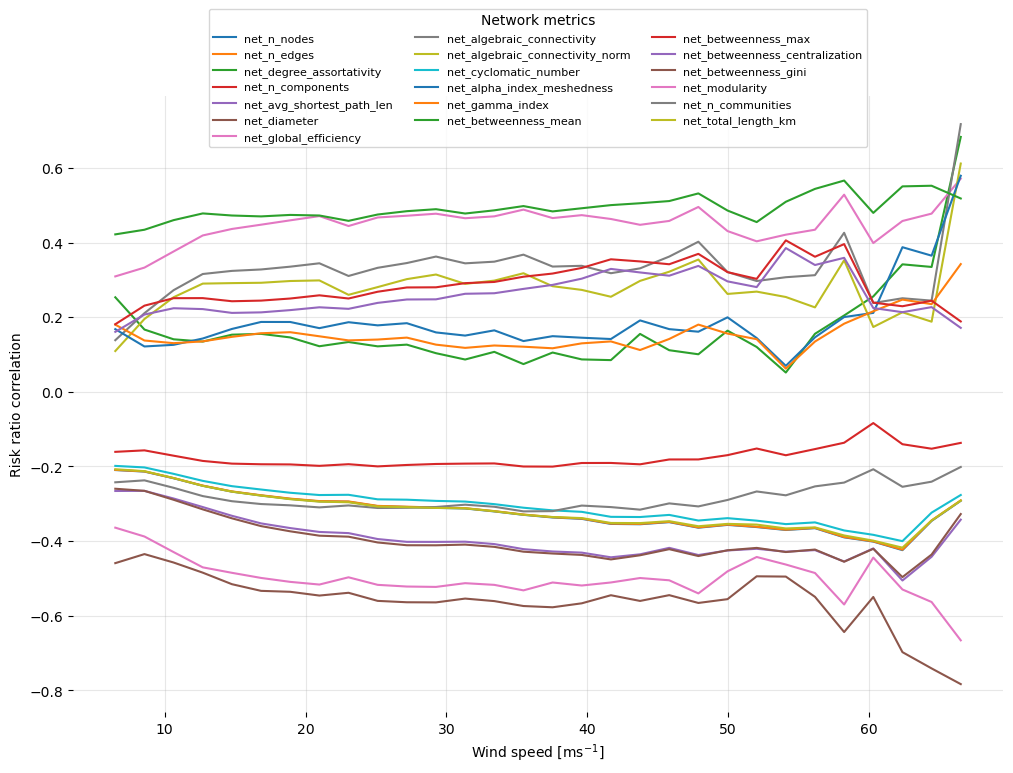

In [99]:
table = df.select_dtypes(include=np.number)
data = []
start = 5
end = 65
n = 30
bin_width = (end - start) / n + 1
bounds = np.linspace(start, end, n)
for lower in bounds:
    upper = lower + bin_width
    x = table[(table["wind_exceedance_ms-1"] > lower) & (table["wind_exceedance_ms-1"] < upper)]
    print(lower, len(x))
    data.append(
            x
            .corr()
            .loc[:, "pop_at_risk_ratio"]
            .rename((upper - lower) / 2 + lower)
            .to_frame()
            .T
    )
corr = pd.concat(data)
corr

to_plot = corr[np.abs(corr) > 0.05].dropna(axis=1, how="any").drop(columns=["pop_at_risk_ratio", "pop_at_risk", "total_pop"])
f, ax = plt.subplots(figsize=(12, 8))
to_plot.plot(ax=ax, legend=False)
ax.set_xlabel("Wind speed [ms$^{-1}$]")
ax.set_ylabel("Risk ratio correlation")
ax.legend(
    fontsize=8,
    title="Network metrics",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    fancybox=True,
)
ax.grid(which="both", alpha=0.3)
ax.set_frame_on(False)